In [1]:
import h5py

In [4]:
mesh_1_file = h5py.File('/scratch/saporito/Frag3D/mesh_1_L_over_500_brittle/data.h5', 'r')

In [5]:
sorted_keys_m1 = sorted(mesh_1_file.keys(), key=lambda x: int(x.split('_')[-1]))
print("Sorted keys in mesh_1_file:", sorted_keys_m1)

Sorted keys in mesh_1_file: ['step_0', 'step_7', 'step_14', 'step_21', 'step_28', 'step_35', 'step_42', 'step_49', 'step_56', 'step_63', 'step_70', 'step_77', 'step_84', 'step_91', 'step_98', 'step_105', 'step_112', 'step_119', 'step_126', 'step_133', 'step_140', 'step_147', 'step_154', 'step_161', 'step_168', 'step_175', 'step_182', 'step_189', 'step_196', 'step_203', 'step_210', 'step_217', 'step_224', 'step_231', 'step_238', 'step_245', 'step_252', 'step_259', 'step_266', 'step_273', 'step_280', 'step_287', 'step_294', 'step_301', 'step_308', 'step_315', 'step_322', 'step_329', 'step_336', 'step_343', 'step_350', 'step_357', 'step_364', 'step_371', 'step_378', 'step_385', 'step_392', 'step_399', 'step_406', 'step_413', 'step_420', 'step_427', 'step_434', 'step_441', 'step_448', 'step_455', 'step_462', 'step_469', 'step_476', 'step_483', 'step_490', 'step_497', 'step_504', 'step_511', 'step_518', 'step_525', 'step_532', 'step_539', 'step_546', 'step_553', 'step_560', 'step_567', 'ste

In [7]:
final_step_mesh_1 = mesh_1_file['step_7714']

In [8]:
print(final_step_mesh_1.attrs.keys())

<KeysViewHDF5 ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']>


In [9]:
final_time = final_step_mesh_1.attrs['time']
print(final_time)

3.999517537478313e-05


In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Savding variation of ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']
# wrt their value in step_0 at each step
econ = []
edis = []
ekin = []
epot = []
erev = []
nb_fragments = []
total_energy = []
for step in sorted_keys_m1:
    step_data = mesh_1_file[step]
    econ.append(step_data.attrs['econ'])
    edis.append(step_data.attrs['edis'])
    ekin.append(step_data.attrs['ekin'])
    epot.append(step_data.attrs['epot'])
    erev.append(step_data.attrs['erev'])
    nb_fragments.append(step_data.attrs['nb_fragments'])
    total_energy.append(step_data.attrs['total_energy'])
steps = np.array(sorted_keys_m1)
econ = np.array(econ)
edis = np.array(edis)
ekin = np.array(ekin)
epot = np.array(epot)
erev = np.array(erev)
nb_fragments = np.array(nb_fragments)
total_energy = np.array(total_energy)

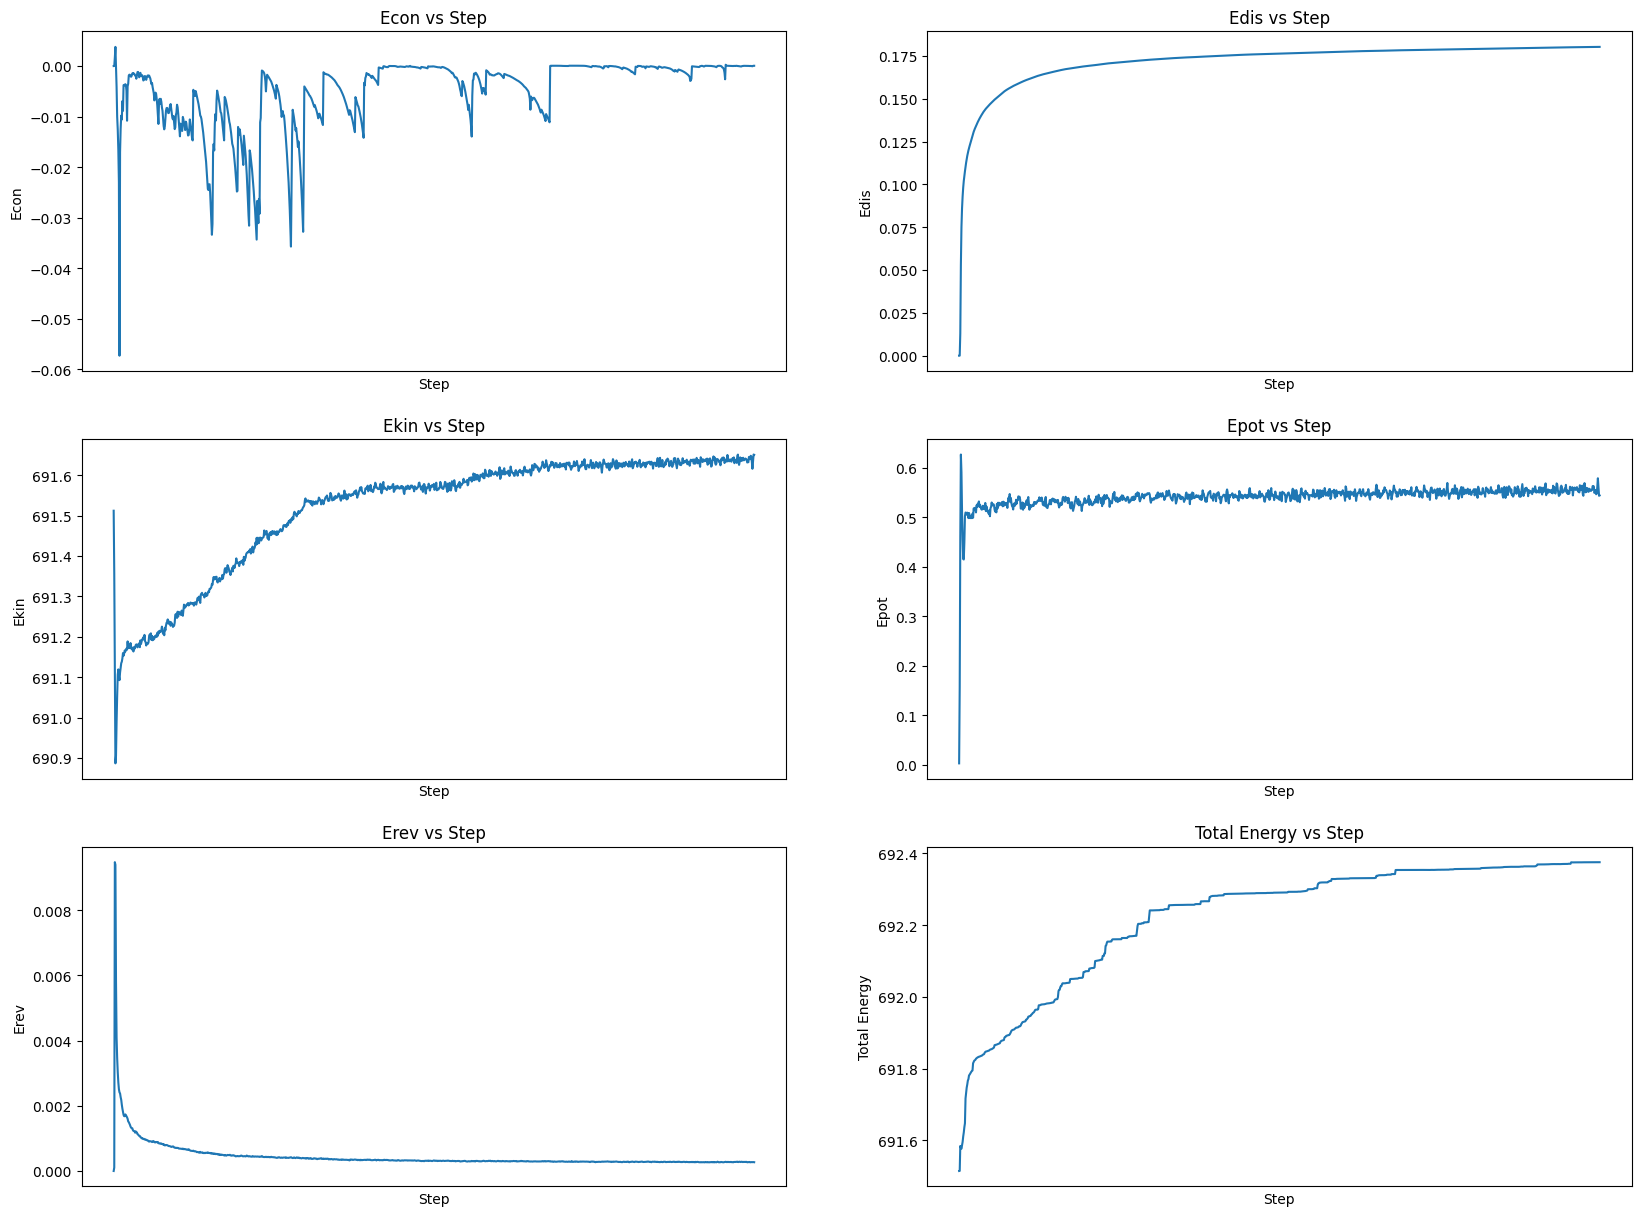

In [13]:
# Plotting the variation of these quantities over time steps
plt.figure(figsize=(20, 15))
plt.subplot(3, 2, 1)
plt.plot(steps, econ, label='Econ')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Econ')
plt.title('Econ vs Step')
plt.subplot(3, 2, 2)
plt.plot(steps, edis, label='Edis')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Edis')
plt.title('Edis vs Step')
plt.subplot(3, 2, 3)
plt.plot(steps, ekin, label='Ekin')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Ekin')
plt.title('Ekin vs Step')
plt.subplot(3, 2, 4)
plt.plot(steps, epot, label='Epot')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Epot')
plt.title('Epot vs Step')
plt.subplot(3, 2, 5)
plt.plot(steps, erev, label='Erev')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Erev')
plt.title('Erev vs Step')
plt.subplot(3, 2, 6)
plt.plot(steps, total_energy, label='Total Energy')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Total Energy')
plt.title('Total Energy vs Step')
plt.show()

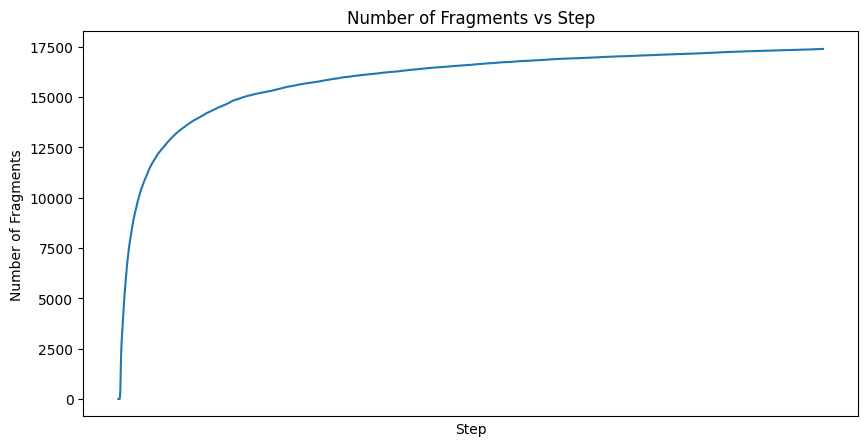

In [14]:
# PLotting number of fragments over time steps
plt.figure(figsize=(10, 5))
plt.plot(steps, nb_fragments, label='Number of Fragments')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Number of Fragments')
plt.title('Number of Fragments vs Step')
plt.show()

In [24]:
import pyvista as pv

2026-04-20 11:51:15.894 (   9.629s) [    7FD13FC29740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_1752586/790276196.py:28: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


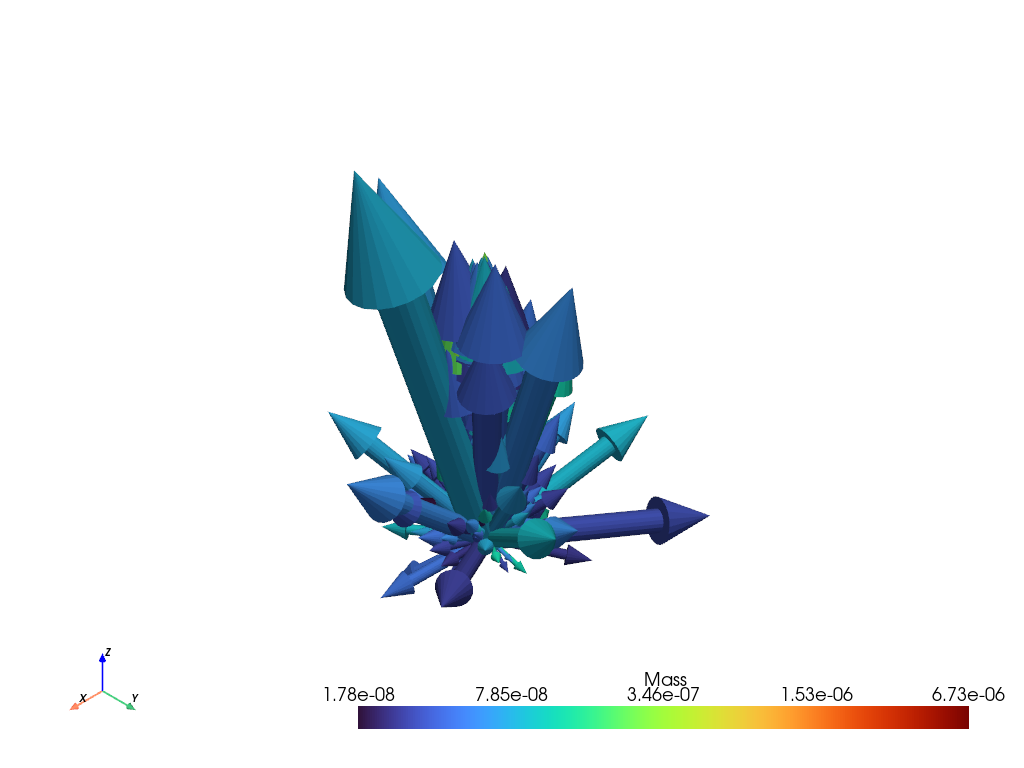

In [14]:
point_cloud = pv.PolyData(final_com)
point_cloud["velocity"] = final_velocities
point_cloud["mass"] = final_masses

# We use the 'velocity' for orientation and magnitude scaling
glyphs = point_cloud.glyph(
    orient="velocity",
    scale=True,  # This scales the arrow length by velocity magnitude
    factor=0.1,
    geom=pv.Arrow(
        tip_radius=0.1,   # Fixed values here
        tip_length=0.25,
        shaft_radius=0.05 
    ),
)

plotter = pv.Plotter()
plotter.add_mesh(
    glyphs,
    scalars="mass",
    cmap="turbo",
    show_scalar_bar=True,
    scalar_bar_args={"title": "Mass"},
    clim=[min_mass, max_mass],
    log_scale=True,
)
plotter.add_axes()
plotter.show()